
## **“The Best Neighborhood in Pittsburgh”**

**Team Name:** *The Pittsburgh Optimizers*  
**Group Members:** *Alden Reagins and Matthew Klapowitz*



## **Introduction**

Communities thrive when people feel safe, supported, and connected, so when our group set out to determine the “best” neighborhood in Pittsburgh, we chose to focus on Quality of Life—a metric that may not attract the most people, but definitely keeps them. We wanted a way to measure the stability and livability that make a neighborhood feel like a genuine community. At first, we considered using cleanliness as a submetric, but we quickly realized it was too narrow and didn’t fully capture how residents actually experience their environment. Instead, we turned to 311 Complaints, a much broader and more honest reflection of neighborhood concerns, covering everything from noise and traffic to damaged streets and cleanliness issues. Paired with Crime per Capita and Trees per Capita, our metric balances safety, environment, and resident sentiment—all essential pieces of what makes people stay. As we explored the data, neighborhoods like Saint Clair stood out with impressively low crime and complaint rates, raising our curiosity even when tree data was less clear. Our approach became less about searching for a perfect statistic and more about understanding the traits that make a neighborhood feel stable, welcoming, and livable—the real foundations of a strong community.




## **The Metric (Your Group’s Overall Metric)**

Building on our focus on Quality of Life, we designed a metric that measures three features we believe define how people actually experience their neighborhoods: Crime per Capita, Trees per Capita, and Complaints per Capita. Each feature comes from a separate dataset—crime from the Criminal Report Final Project file, trees from the Greenery Level Final dataset, and resident concerns from the 311 Reports Final dataset—allowing us to look at safety, environment, and public sentiment from three different angles. Lower crime and fewer complaints reflect daily stability and comfort, while more trees contribute to a healthier and more inviting environment. To make the neighborhoods comparable, we scaled each metric in its raw form and then combined them into a weighted average that reflects their importance in shaping Quality of Life. We gave crime the highest weight (0.50), complaints the next (0.35), and trees the final (0.15), balancing safety, community feedback, and environmental quality. Our final formula,


***QoL Score=0.50(Crime Scaled)+0.35(Complaints Scaled)+0.15(Trees Scaled)***

allowed us to merge these three datasets into one cohesive score and compare neighborhoods on the aspects of life that matter most to long-term community stability.


# Submetrics

## Alden - Crime

## Introduction

We decided to pick Quality of Life as our metric and we believe there are several factors that impact the quality of someone's life. I'm going to cover the one that weighs the most which is safety. I don't believe that you can have a good quality of life if you are always scared for your life. To cover safety I am exploring submetric of crime and how it relates to the safety of a neighborhood. I explore both the raw number of crime in a neighborhood and the crime per capita in a neighborhood to give an accurate depiction of the neighborhood. 



In [1]:
import pandas as pd
df = pd.read_csv("Crime Final Project.csv", low_memory=False)
grouped = (
    df
    .groupby(["Neighborhood", "NIBRS_Crime_Against"])
    .size()
    .reset_index(name="Crime_Count")
)
categories = ["Person", "Property", "Group B"]
for cat in categories:
    safest_5 = (
        grouped[grouped["NIBRS_Crime_Against"] == cat]
        .sort_values("Crime_Count", ascending=True) 
        .head(5)
    )  
    print(f"\nTop 5 safest neighborhoods for {cat} crimes (fewest incidents):")
    print(safest_5)



Top 5 safest neighborhoods for Person crimes (fewest incidents):
       Neighborhood NIBRS_Crime_Against  Crime_Count
267       Ridgemont              Person            3
263   Regent Square              Person            5
327  Swisshelm Park              Person            7
271     Saint Clair              Person            7
81        Chartiers              Person            9

Top 5 safest neighborhoods for Property crimes (fewest incidents):
      Neighborhood NIBRS_Crime_Against  Crime_Count
272    Saint Clair            Property            8
268      Ridgemont            Property            9
82       Chartiers            Property           16
148           Hays            Property           18
220  New Homestead            Property           18

Top 5 safest neighborhoods for Group B crimes (fewest incidents):
      Neighborhood NIBRS_Crime_Against  Crime_Count
270    Saint Clair             Group B            6
80       Chartiers             Group B           12
266      Ridg

This cell loads the crime data, groups it by neighborhood and crime type, and prints the five areas with the fewest Person, Property, and Group B crimes. It gives a basic view of which neighborhoods appear safest based on raw incident counts, without yet considering crime severity or neighborhood population size.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Crime Final Project.csv", low_memory=False)

grouped = (
    df
    .groupby(["Neighborhood", "NIBRS_Crime_Against"])
    .size()
    .reset_index(name="Crime_Count")
)

This cell groups crimes by neighborhood again, but stores the results in a DataFrame for plotting. It creates a reusable structure for visual bar charts of each crime category.

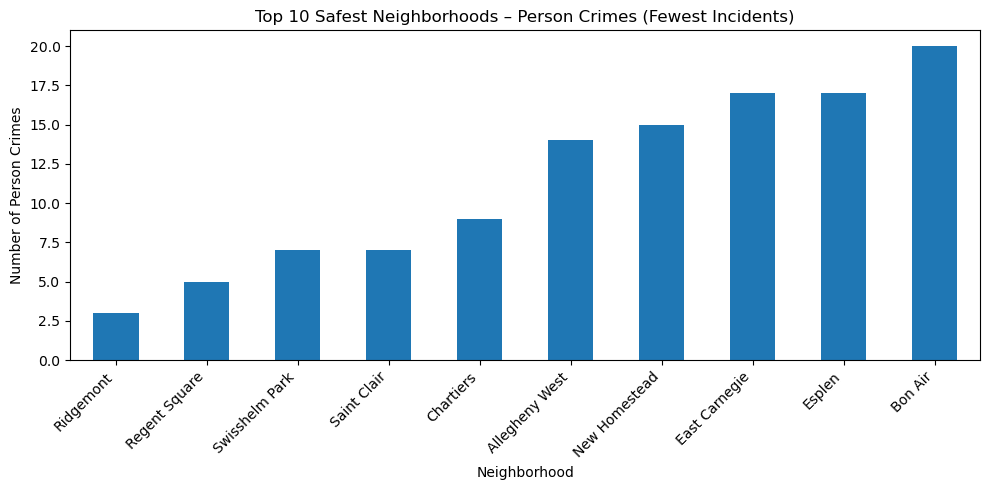

In [3]:
safest_person = (
    grouped[grouped["NIBRS_Crime_Against"] == "Person"]
    .sort_values("Crime_Count", ascending=True)
    .head(10)
)

ax = safest_person.plot(
    kind="bar",
    x="Neighborhood",
    y="Crime_Count",
    legend=False,
    figsize=(10, 5),
    title="Top 10 Safest Neighborhoods – Person Crimes (Fewest Incidents)"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Person Crimes")
plt.tight_layout()
plt.show()

This cell charts the ten neighborhoods with the fewest Person crimes. It highlights which areas appear safest from a personal-safety perspective based on raw incident counts.

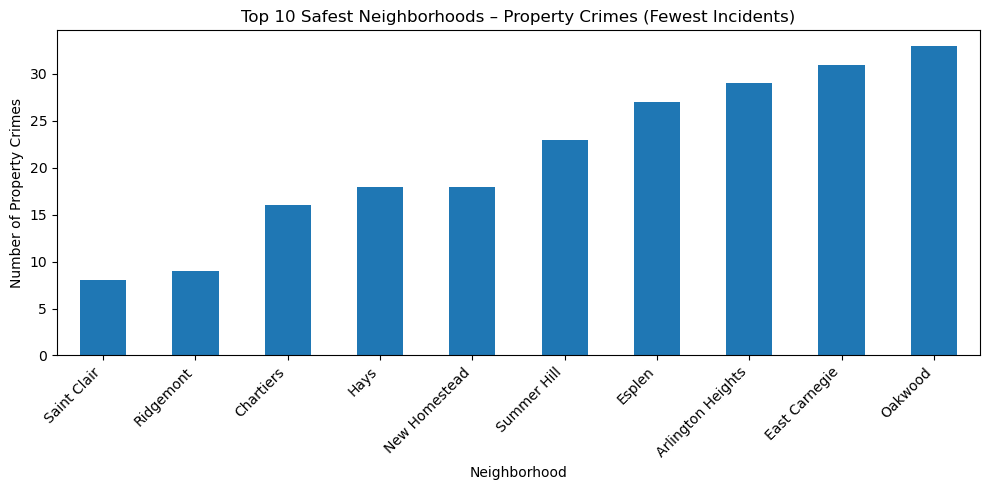

In [4]:
safest_property = (
    grouped[grouped["NIBRS_Crime_Against"] == "Property"]
    .sort_values("Crime_Count", ascending=True)
    .head(10)
)

ax = safest_property.plot(
    kind="bar",
    x="Neighborhood",
    y="Crime_Count",
    legend=False,
    figsize=(10, 5),
    title="Top 10 Safest Neighborhoods – Property Crimes (Fewest Incidents)"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Property Crimes")
plt.tight_layout()
plt.show()

This cell charts the ten neighborhoods with the fewest Property crimes. It highlights which areas appear safer in terms of protecting belongings and spaces, complementing the earlier Person-crime comparison.

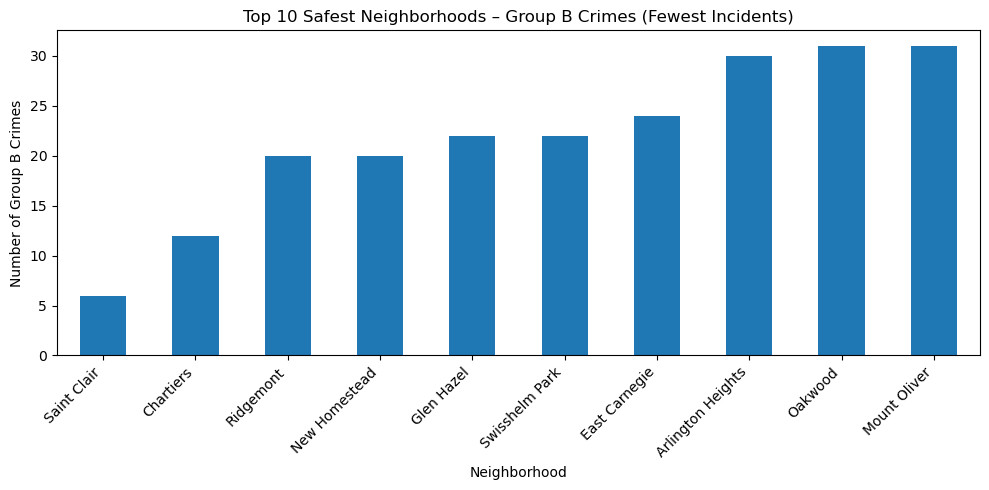

In [5]:
safest_groupb = (
    grouped[grouped["NIBRS_Crime_Against"] == "Group B"]
    .sort_values("Crime_Count", ascending=True)
    .head(10)
)

ax = safest_groupb.plot(
    kind="bar",
    x="Neighborhood",
    y="Crime_Count",
    legend=False,
    figsize=(10, 5),
    title="Top 10 Safest Neighborhoods – Group B Crimes (Fewest Incidents)"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Group B Crimes")
plt.tight_layout()
plt.show()

This cell charts the ten neighborhoods with the fewest Group B crimes. These offenses are generally less serious but still affect how a neighborhood is experienced, helping show that rankings can shift depending on which crime category is considered.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# load data
crime_df = pd.read_csv("Crime Final Project.csv", low_memory=False)
pop_df   = pd.read_csv("preliminarycitypittsburghneighborhood_pl94171summary-2.csv")

# fix neighborhood names (strip spaces, normalize dashes)
def fix_name(s):
    if pd.isna(s):
        return s
    return s.strip().replace("–", "-").replace("—", "-")

crime_df["Neighborhood_norm"] = crime_df["Neighborhood"].map(fix_name)
pop_df["Neighborhood_norm"]   = pop_df["Neighborhood"].map(fix_name)

# combine some separate neighborhoods so they line up with the population file
combine = {
    "Arlington": "Arlington - Arlington Heights (Combined)",
    "Arlington Heights": "Arlington - Arlington Heights (Combined)",
    "Central Business District": "Central Business District (Downtown)",
    "Chartiers": "Chartiers City",
    "Mount Oliver": "Mt. Oliver",
    "Saint Clair": "St. Clair",
    "Southshore": "South Shore",
    "Spring Hill-City View": "Spring Hill-City"
}

crime_df["Neighborhood_fixed"] = crime_df["Neighborhood_norm"].replace(combine)


This cell loads the crime and population data, then standardizes neighborhood names so both sources align. Matching the labels prevents distorted comparisons when crime counts are later adjusted by population.

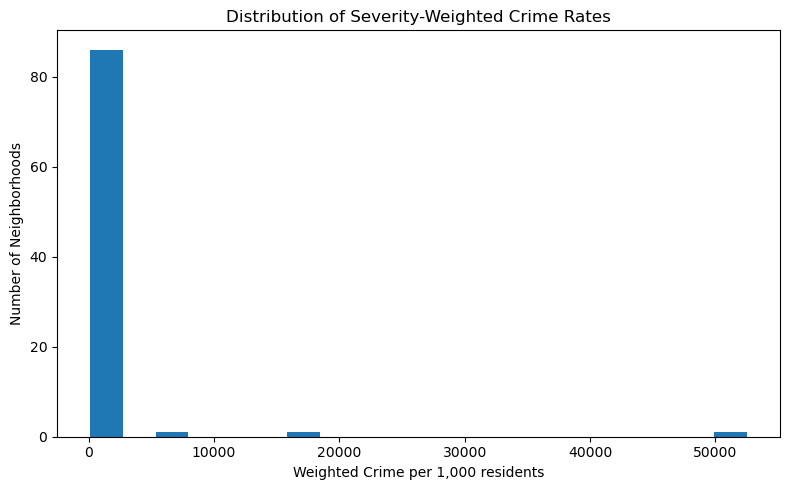

In [7]:
# group crime by neighborhood + crime-against category
grouped = (
    crime_df
    .dropna(subset=["Neighborhood_fixed", "NIBRS_Crime_Against"])
    .groupby(["Neighborhood_fixed", "NIBRS_Crime_Against"])
    .size()
    .reset_index(name="Crime_Count")
)

# pivot: one row per neighborhood, columns for Person / Property / Group B
crime_pivot = (
    grouped
    .pivot(index="Neighborhood_fixed", columns="NIBRS_Crime_Against", values="Crime_Count")
    .fillna(0)
    .reset_index()
)

# make sure all three columns exist
for col in ["Person", "Property", "Group B"]:
    if col not in crime_pivot.columns:
        crime_pivot[col] = 0

# pull 2020 population and align neighborhood names
pop_2020 = (
    pop_df[["Neighborhood_norm", "2020_Total_Population"]]
    .dropna()
    .rename(columns={"Neighborhood_norm": "Neighborhood_fixed"})
)

# merge crime + population
crime_metrics = crime_pivot.merge(pop_2020, on="Neighborhood_fixed", how="inner")

# avoid divide-by-zero
crime_metrics = crime_metrics[crime_metrics["2020_Total_Population"] > 0]

# apply severity weights (Option 2)
person_wt = 5
property_wt = 2
groupb_wt = 1

crime_metrics["Weighted_Crime_Total"] = (
    person_wt * crime_metrics["Person"] +
    property_wt * crime_metrics["Property"] +
    groupb_wt * crime_metrics["Group B"]
)

# weighted crime per 1,000 residents
crime_metrics["Weighted_Crime_per_1000"] = (
    crime_metrics["Weighted_Crime_Total"] / crime_metrics["2020_Total_Population"] * 1000
)

# scale crime so that higher = safer (1 = safest, 0 = worst)
c_min = crime_metrics["Weighted_Crime_per_1000"].min()
c_max = crime_metrics["Weighted_Crime_per_1000"].max()

if c_max == c_min:
    crime_metrics["Crime_Scaled"] = 1.0
else:
    scaled_raw = (crime_metrics["Weighted_Crime_per_1000"] - c_min) / (c_max - c_min)
    crime_metrics["Crime_Scaled"] = 1 - scaled_raw

# sort by weighted crime per 1,000 (ascending = safest first)
crime_metrics_sorted = crime_metrics.sort_values("Weighted_Crime_per_1000", ascending=True)

# quick look at the table
crime_metrics_sorted.head()

# ----- graph for this cell: distribution of weighted crime per 1,000 -----
plt.figure(figsize=(8, 5))
plt.hist(crime_metrics["Weighted_Crime_per_1000"], bins=20)
plt.xlabel("Weighted Crime per 1,000 residents")
plt.ylabel("Number of Neighborhoods")
plt.title("Distribution of Severity-Weighted Crime Rates")
plt.tight_layout()
plt.show()


This cell creates a severity-weighted, per-capita safety metric. It merges crime totals with population data, applies higher weights to Person crimes and lower weights to Property and Group B offenses, and then calculates a weighted score per 1,000 residents. The result reflects both crime frequency and seriousness, forming the basis of my comparison of neighborhood safety.

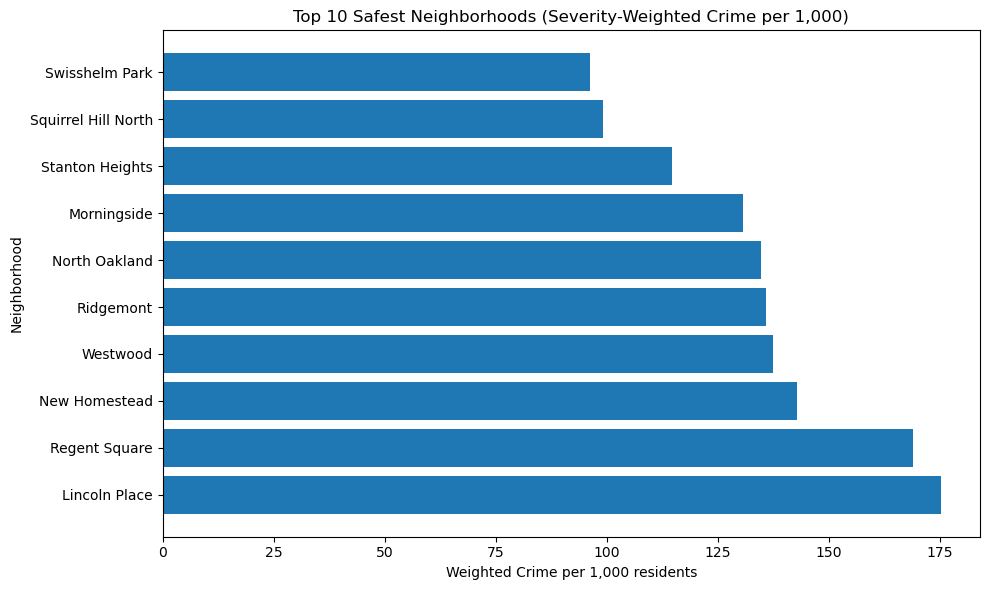

In [8]:
# take the 10 safest (lowest weighted crime per 1,000 residents)
top10_safest = crime_metrics_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_safest["Neighborhood_fixed"], top10_safest["Weighted_Crime_per_1000"])
plt.xlabel("Weighted Crime per 1,000 residents")
plt.ylabel("Neighborhood")
plt.title("Top 10 Safest Neighborhoods (Severity-Weighted Crime per 1,000)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


This cell uses the severity-weighted crime per 1,000 residents to plot the ten safest neighborhoods. The chart highlights which areas stand out once both crime seriousness and population size are considered, offering a clearer picture than raw counts alone.

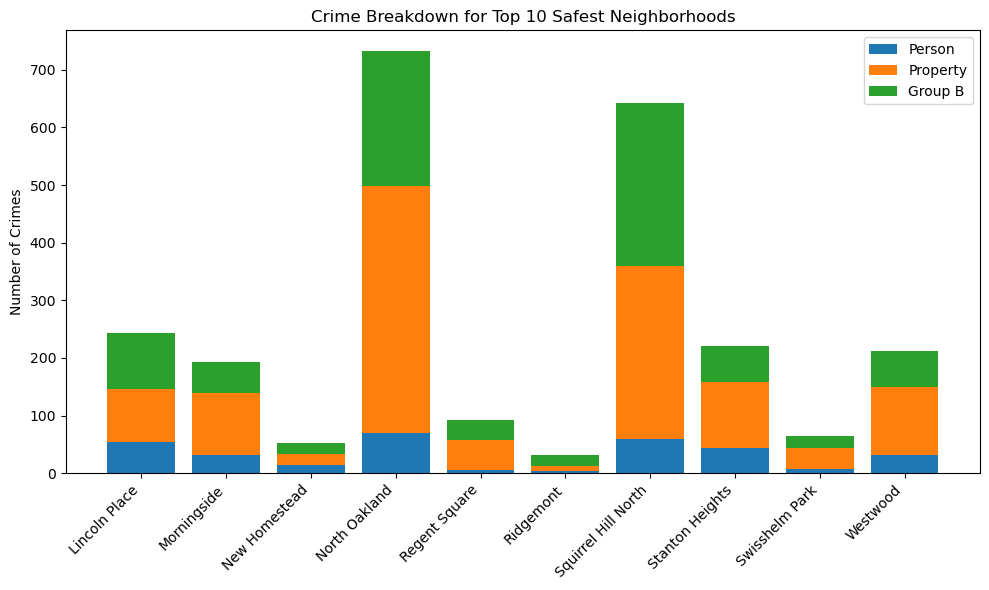

In [9]:
# filter the original pivot to only the top10 safest neighborhoods
top10_names = top10_safest["Neighborhood_fixed"].tolist()

top10_breakdown = (
    crime_pivot[crime_pivot["Neighborhood_fixed"].isin(top10_names)]
    .set_index("Neighborhood_fixed")
    [["Person", "Property", "Group B"]]
    .sort_index()
)

plt.figure(figsize=(10, 6))
bottom = None

for col in ["Person", "Property", "Group B"]:
    if bottom is None:
        bottom = top10_breakdown[col]
        plt.bar(top10_breakdown.index, top10_breakdown[col], label=col)
    else:
        plt.bar(top10_breakdown.index, top10_breakdown[col], bottom=bottom, label=col)
        bottom = bottom + top10_breakdown[col]

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Crimes")
plt.title("Crime Breakdown for Top 10 Safest Neighborhoods")
plt.legend()
plt.tight_layout()
plt.show()


This cell breaks down the ten safest neighborhoods by crime category using a stacked bar chart. It shows not just low totals, but also fewer serious Person crimes, helping validate the severity-weighted metric.

## Conclusion ## 

Overall, this group of cells moves from simple crime counts to a graph to a more realistic way of thinking about neighborhood safety. The early graphs rank neighborhoods by raw counts of Person, Property, and Group B crimes. This makes it useful for understanding, but they treat all incidents as equally important and ignore how many people live in each area. By contrast, the later steps combine crime severity and population into a single, weighted crime rate per 1,000 residents and then scale that measure so safer neighborhoods receive higher scores. This paints a better picture for the amount of crime happening in each neighborhood. In conclusion, I found that the safest neighborhood is **Swisshelm**, this is due to it having the least amount of crime per 1000 people in the neighborhood. 

## Matthew - Complaints

## Introduction 

The second part of our Quality of Life metric is how stress-free the neighborhood. If you are always stressing about small things your life becomes less enjoyable. So I decided to track this stress-free environment by calculating the amount of complaints made in each neighborhood then finding the amount per capita, that way we could create an accurate graph and scaled dataset to plug into a formula for our overarching metric. 

In [10]:
import pandas as pd

df_complaints = pd.read_csv("Complaints.zip", compression="zip", low_memory=False)
df_complaints = df_complaints.dropna(subset=["NEIGHBORHOOD", "CREATED_ON"])

df_complaints["CREATED_ON"] = pd.to_datetime(df_complaints["CREATED_ON"], errors="coerce")
df_complaints = df_complaints.dropna(subset=["CREATED_ON"])  # drop rows that failed to parse
df_complaints["Year"] = df_complaints["CREATED_ON"].dt.year

complaints_by_neighborhood = (
    df_complaints
    .groupby("NEIGHBORHOOD")
    .size()
    .reset_index(name="Complaint_Count")
)

top10_least_complaints = (
    complaints_by_neighborhood
    .sort_values("Complaint_Count", ascending=True)
    .head(10)
)

print("Top 10 neighborhoods with the least total complaints:")
print(top10_least_complaints)

top10_neighborhoods = top10_least_complaints["NEIGHBORHOOD"].tolist()
df_top10 = df_complaints[df_complaints["NEIGHBORHOOD"].isin(top10_neighborhoods)]

complaints_per_year = (
    df_top10
    .groupby(["NEIGHBORHOOD", "Year"])
    .size()
    .reset_index(name="Complaint_Count")
)

print("\nYearly complaint counts (sorted from lowest to highest) for each of the top 10 neighborhoods:")
for nhood in top10_neighborhoods:
    sub = (
        complaints_per_year[complaints_per_year["NEIGHBORHOOD"] == nhood]
        .sort_values("Complaint_Count", ascending=True)
    )
    print(f"\nNeighborhood: {nhood}")
    print(sub[["Year", "Complaint_Count"]].to_string(index=False))

Top 10 neighborhoods with the least total complaints:
            NEIGHBORHOOD  Complaint_Count
52  Mount Oliver Borough               64
4      Arlington Heights              140
35            Glen Hazel              443
58     Northview Heights              661
26         East Carnegie              666
67             Ridgemont              714
20        Chartiers City              823
78             St. Clair              888
31             Fairywood             1048
37                  Hays             1157

Yearly complaint counts (sorted from lowest to highest) for each of the top 10 neighborhoods:

Neighborhood: Mount Oliver Borough
 Year  Complaint_Count
 2021                2
 2018                5
 2020                5
 2022                5
 2015                6
 2017                6
 2019                9
 2016               26

Neighborhood: Arlington Heights
 Year  Complaint_Count
 2020                6
 2015               12
 2016               14
 2018               1

This cell identifies neighborhoods with the fewest service complaints. After cleaning the data and extracting the year, I group complaints by neighborhood and check whether low totals stay consistent over time, rather than being one-year anomalies.

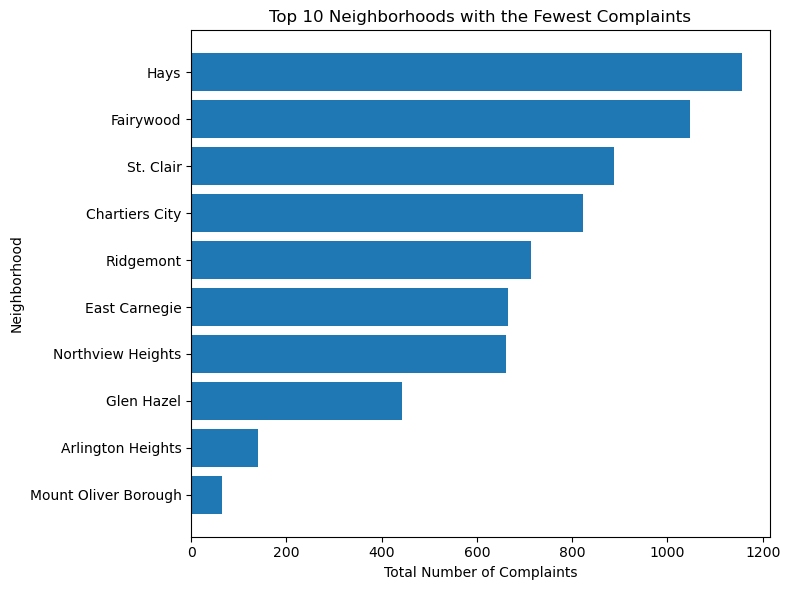

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the complaints dataset
df_complaints = pd.read_csv("Complaints.zip", compression="zip", low_memory=False)
# 2. Drop rows with missing neighborhood
df_complaints = df_complaints.dropna(subset=["NEIGHBORHOOD"])

complaints_by_neighborhood = (
    df_complaints
    .groupby("NEIGHBORHOOD")
    .size()
    .reset_index(name="Complaint_Count")
)

top10_least = (
    complaints_by_neighborhood
    .sort_values("Complaint_Count", ascending=True)
    .head(10)
)

plt.figure(figsize=(8, 6))
plt.barh(
    top10_least["NEIGHBORHOOD"],
    top10_least["Complaint_Count"]
)
plt.xlabel("Total Number of Complaints")
plt.ylabel("Neighborhood")
plt.title("Top 10 Neighborhoods with the Fewest Complaints")
plt.tight_layout()
plt.show()

This cell visualizes the neighborhoods with the fewest complaints using a horizontal bar chart, making it easy to compare low-complaint areas at a glance. It establishes a baseline of which places report fewer issues before adjusting for population or usage.

In [12]:
import pandas as pd

# load complaints and population data
df_complaints = pd.read_csv("Complaints.zip", compression="zip", low_memory=False)
df_complaints = df_complaints.dropna(subset=["NEIGHBORHOOD"])

pop_df = pd.read_csv("preliminarycitypittsburghneighborhood_pl94171summary-2.csv", low_memory=False)

# normalize neighborhood names (strip spaces, fix dashes)
def fix_name(s):
    if pd.isna(s):
        return s
    return s.strip().replace("–", "-").replace("—", "-")

df_complaints["Neighborhood_norm"] = df_complaints["NEIGHBORHOOD"].map(fix_name)
pop_df["Neighborhood_norm"]       = pop_df["Neighborhood"].map(fix_name)

# same combined-neighborhood mapping used in Crime and Trees
combine = {
    "Arlington": "Arlington - Arlington Heights (Combined)",
    "Arlington Heights": "Arlington - Arlington Heights (Combined)",
    "Central Business District": "Central Business District (Downtown)",
    "Chartiers": "Chartiers City",
    "Mount Oliver": "Mt. Oliver",
    "Saint Clair": "St. Clair",
    "Southshore": "South Shore",
    "Spring Hill-City View": "Spring Hill-City"
}

df_complaints["Neighborhood_fixed"] = df_complaints["Neighborhood_norm"].replace(combine)


This cell standardizes neighborhood names in the complaint data to match the population dataset, combining the same pairs used earlier. Aligning labels prevents mismatches that would distort complaint rates later.

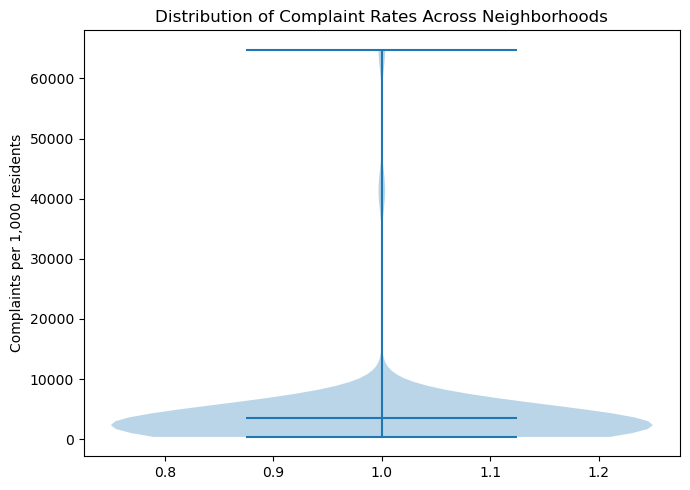

,Neighborhood_fixed,Complaint_Count,2020_Total_Population,Complaints_per_1000
56,Northview Heights,661,1769,373.657434
54,North Oakland,5945,10691,556.075203
9,Bluff,3864,5882,656.919415
34,Glen Hazel,443,659,672.230653
81,Terrace Village,1954,2320,842.241379


In [13]:
import matplotlib.pyplot as plt

# count complaints per neighborhood
complaint_counts = (
    df_complaints
    .dropna(subset=["Neighborhood_fixed"])
    .groupby("Neighborhood_fixed")
    .size()
    .reset_index(name="Complaint_Count")
)

# pull 2020 population and align names
pop_2020 = (
    pop_df[["Neighborhood_norm", "2020_Total_Population"]]
    .dropna()
    .rename(columns={"Neighborhood_norm": "Neighborhood_fixed"})
)

# combine population + complaints
complaints_metrics = complaint_counts.merge(pop_2020, on="Neighborhood_fixed", how="inner")
complaints_metrics = complaints_metrics[complaints_metrics["2020_Total_Population"] > 0]

# complaints per 1000 residents
complaints_metrics["Complaints_per_1000"] = (
    complaints_metrics["Complaint_Count"] / complaints_metrics["2020_Total_Population"] * 1000
)

# sort from lowest to highest complaints per capita (safest first)
complaints_metrics_sorted = complaints_metrics.sort_values("Complaints_per_1000", ascending=True)

# violin plot of distribution of complaints per 1000
plt.figure(figsize=(7, 5))
plt.violinplot(complaints_metrics_sorted["Complaints_per_1000"], vert=True, showmeans=True)
plt.ylabel("Complaints per 1,000 residents")
plt.title("Distribution of Complaint Rates Across Neighborhoods")
plt.tight_layout()
plt.show()

complaints_metrics_sorted.head()


This cell calculates complaints per 1,000 residents by merging complaint totals with population data. The violin plot shows how complaint intensity varies across neighborhoods, revealing uneven patterns that raw totals can hide.

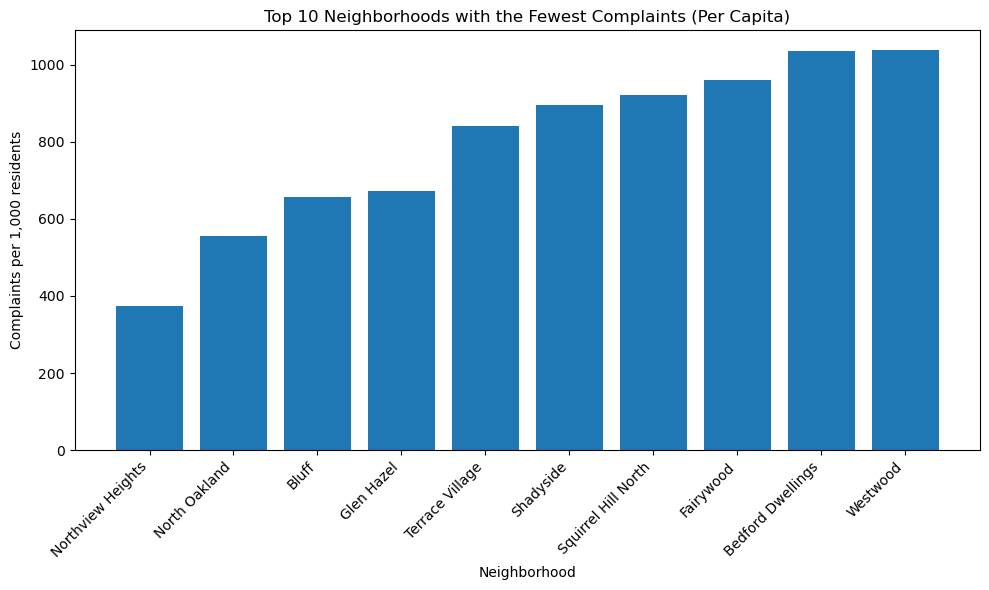

In [14]:
# top 10 neighborhoods with the fewest complaints per 1,000 residents
top10_safest_complaints = complaints_metrics_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.bar(
    top10_safest_complaints["Neighborhood_fixed"],
    top10_safest_complaints["Complaints_per_1000"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Complaints per 1,000 residents")
plt.xlabel("Neighborhood")
plt.title("Top 10 Neighborhoods with the Fewest Complaints (Per Capita)")
plt.tight_layout()
plt.show()


This cell ranks the ten neighborhoods with the fewest complaints per 1,000 residents and plots them in a bar chart. It highlights areas where residents experience fewer issues overall, distinguishing genuinely smooth-running neighborhoods from those that just file fewer complaints.

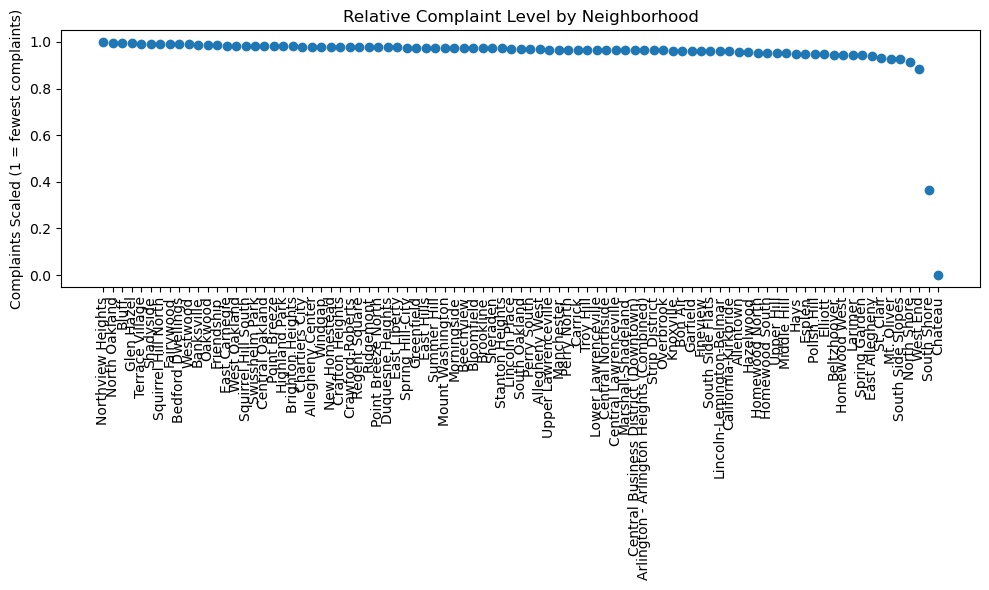

In [15]:
# scale so that 1 = best (fewest complaints), 0 = worst (most complaints)
c_min = complaints_metrics["Complaints_per_1000"].min()
c_max = complaints_metrics["Complaints_per_1000"].max()

if c_max == c_min:
    complaints_metrics["Complaints_Scaled"] = 1.0
else:
    scaled_raw = (complaints_metrics["Complaints_per_1000"] - c_min) / (c_max - c_min)
    complaints_metrics["Complaints_Scaled"] = 1 - scaled_raw  # fewer complaints => higher score

# sort again for plotting and inspection
complaints_metrics_sorted2 = complaints_metrics.sort_values("Complaints_per_1000", ascending=True)

plt.figure(figsize=(10, 6))
plt.scatter(
    complaints_metrics_sorted2["Neighborhood_fixed"],
    complaints_metrics_sorted2["Complaints_Scaled"]
)
plt.xticks(rotation=90)
plt.ylabel("Complaints Scaled (1 = fewest complaints)")
plt.title("Relative Complaint Level by Neighborhood")
plt.tight_layout()
plt.show()


This cell scales complaints per 1,000 residents to a 0–1 score and inverts it so fewer complaints yield higher values. The scatter plot shows how each neighborhood fits into this standardized metric, allowing the complaint measure to be combined with crime and tree scores later.

In [16]:
# ordered from best (fewest complaints) to worst
complaints_final_sorted = complaints_metrics.sort_values("Complaints_Scaled", ascending=False)

complaints_final_sorted.head(15)


,Neighborhood_fixed,Complaint_Count,2020_Total_Population,Complaints_per_1000,Complaints_Scaled
56,Northview Heights,661,1769,373.657434,1.000000
54,North Oakland,5945,10691,556.075203,0.997168
9,Bluff,3864,5882,656.919415,0.995603
34,Glen Hazel,443,659,672.230653,0.995365
81,Terrace Village,1954,2320,842.241379,0.992726
66,Shadyside,13736,15317,896.781354,0.991879
74,Squirrel Hill North,10956,11879,922.299857,0.991483
30,Fairywood,1048,1092,959.706960,0.990902
5,Bedford Dwellings,1435,1386,1035.353535,0.989728
87,Westwood,3457,3332,1037.515006,0.989694


This cell ranks neighborhoods by their scaled complaint scores. After cleaning and adjusting for population, complaints now serve as a comparable metric that can be used alongside crime and tree measures to evaluate overall neighborhood experience.

## Conclusion ##

The complaints metric shows how frequently residents experience discomfort in services and conditions of their neighborhoods. Working with the raw totals vs the per capita calculations depicts which areas have a smoother day-to-day living process. By cleaning the names, aligning datasets, and scaling the results, I can put complaints into a format that fits into our QoL formula. In conclusions the neighborhood with the best day-to-day living is **Northview Heights**. 


## Trees

## Introduction

The last part of our overarching metric for Quality of Life is how stress-relieving the environment is. I decided to pick a submetric that could be calculated in lots of different ways but I decided to use the number of trees to find this number. Who doesn't love relaxing in nature and breathing fresh, clean air. I did the same thing as the other submetrics where I ended up creating a scaled dataset so that we could factor them into the metric formula. 


In [17]:
import pandas as pd

df_trees = pd.read_csv("Trees.csv", low_memory=False)

conditions = ["Very Good", "Good", "Fair", "Poor", "Critical"]
df_trees_filtered = df_trees[df_trees["condition"].isin(conditions)]

tree_counts_long = (
    df_trees_filtered
    .groupby(["neighborhood", "condition"])
    .size()
    .reset_index(name="Tree_Count")
)

tree_counts_wide = (
    tree_counts_long
    .pivot(index="neighborhood", columns="condition", values="Tree_Count")
    .fillna(0)
    .astype(int)
)

tree_counts_wide["Total_Trees"] = (
    tree_counts_wide["Critical"]
    + tree_counts_wide["Fair"]
    + tree_counts_wide["Good"]
    + tree_counts_wide["Poor"]
    + tree_counts_wide["Very Good"]
)

top10 = (
    tree_counts_wide
    .sort_values("Total_Trees", ascending=False)
    .head(10)
)

print("Top 10 neighborhoods by total number of trees:")
for neighborhood, row in top10.iterrows():
    print(f"\nNeighborhood: {neighborhood}")
    print(f"  Total trees: {row['Total_Trees']}")
    for cond in conditions:
        print(f"  {cond}: {row[cond]}")

Top 10 neighborhoods by total number of trees:

Neighborhood: Squirrel Hill South
  Total trees: 4805
  Very Good: 76
  Good: 1978
  Fair: 1916
  Poor: 777
  Critical: 58

Neighborhood: Highland Park
  Total trees: 2680
  Very Good: 17
  Good: 1116
  Fair: 1083
  Poor: 440
  Critical: 24

Neighborhood: Squirrel Hill North
  Total trees: 1861
  Very Good: 19
  Good: 668
  Fair: 996
  Poor: 168
  Critical: 10

Neighborhood: South Side Flats
  Total trees: 1430
  Very Good: 15
  Good: 890
  Fair: 417
  Poor: 79
  Critical: 29

Neighborhood: Shadyside
  Total trees: 1279
  Very Good: 17
  Good: 311
  Fair: 720
  Poor: 197
  Critical: 34

Neighborhood: East Liberty
  Total trees: 1220
  Very Good: 36
  Good: 450
  Fair: 565
  Poor: 118
  Critical: 51

Neighborhood: Point Breeze
  Total trees: 1152
  Very Good: 17
  Good: 335
  Fair: 667
  Poor: 117
  Critical: 16

Neighborhood: Bloomfield
  Total trees: 1151
  Very Good: 32
  Good: 524
  Fair: 444
  Poor: 126
  Critical: 25

Neighborhood: C

This cell filters trees with valid condition ratings, groups them by neighborhood, and summarizes how many are in each condition. Pivoting the results and adding a total count highlights which neighborhoods have the most trees and how healthy they are, without yet considering population.

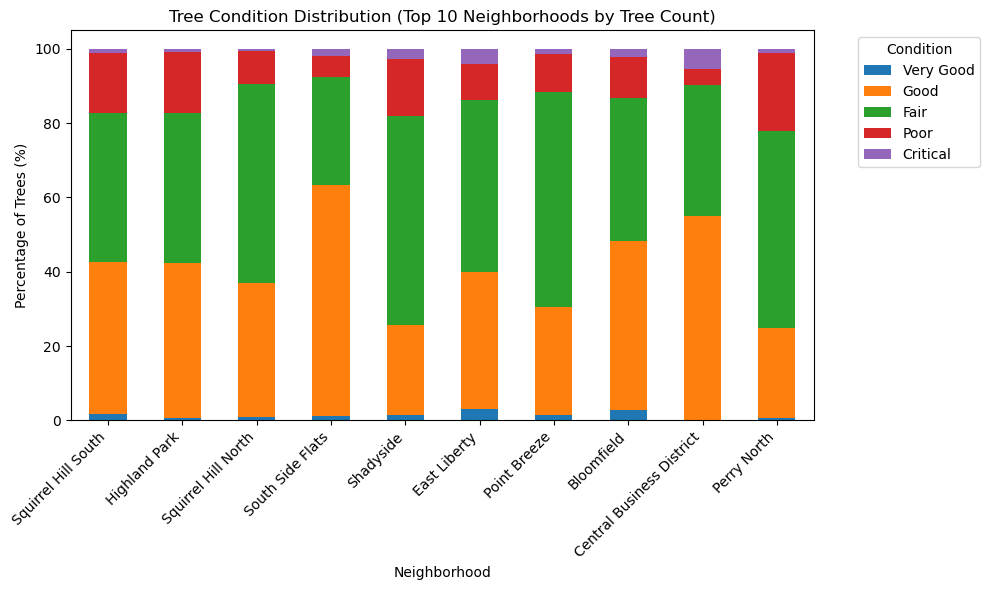

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df_trees = pd.read_csv("Trees.csv", low_memory=False)

conditions = ["Very Good", "Good", "Fair", "Poor", "Critical"]
df_trees_filtered = df_trees[df_trees["condition"].isin(conditions)]

tree_counts_long = (
    df_trees_filtered
    .groupby(["neighborhood", "condition"])
    .size()
    .reset_index(name="Tree_Count")
)

tree_counts_wide = (
    tree_counts_long
    .pivot(index="neighborhood", columns="condition", values="Tree_Count")
    .fillna(0)
    .astype(int)
)

tree_counts_wide["Total_Trees"] = tree_counts_wide[conditions].sum(axis=1)

top10 = (
    tree_counts_wide
    .sort_values("Total_Trees", ascending=False)
    .head(10)
)

top10_percent = top10[conditions].div(top10["Total_Trees"], axis=0) * 100

ax = top10_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Neighborhood")
plt.ylabel("Percentage of Trees (%)")
plt.title("Tree Condition Distribution (Top 10 Neighborhoods by Tree Count)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

This cell looks at the top ten neighborhoods by tree count but compares them by tree health percentages using a stacked bar chart. It shows that having many trees doesn’t guarantee quality if a large share are in poor condition.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# load trees + population data
trees_df = pd.read_csv("Trees.csv", low_memory=False)
pop_df   = pd.read_csv("preliminarycitypittsburghneighborhood_pl94171summary-2.csv", low_memory=False)

# clean the neighborhood field (strip spaces, normalize dashes)
def fix_name(s):
    if pd.isna(s):
        return s
    return s.strip().replace("–", "-").replace("—", "-")

# IMPORTANT: use 'neighborhood' (lowercase) from Trees.csv
trees_df["Neighborhood_norm"] = trees_df["neighborhood"].map(fix_name)
pop_df["Neighborhood_norm"]   = pop_df["Neighborhood"].map(fix_name)

# match Crime notebook's neighborhood merging
combine = {
    "Arlington": "Arlington - Arlington Heights (Combined)",
    "Arlington Heights": "Arlington - Arlington Heights (Combined)",
    "Central Business District": "Central Business District (Downtown)",
    "Chartiers": "Chartiers City",
    "Mount Oliver": "Mt. Oliver",
    "Saint Clair": "St. Clair",
    "Southshore": "South Shore",
    "Spring Hill-City View": "Spring Hill-City"
}

trees_df["Neighborhood_fixed"] = trees_df["Neighborhood_norm"].replace(combine)


This cell standardizes neighborhood names in the trees data to match the population dataset, merging the same paired areas used earlier. Aligning labels ensures tree counts can be accurately compared to population later.

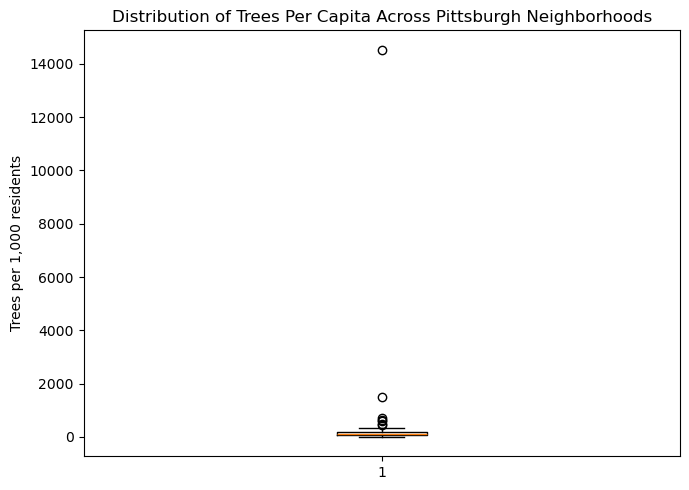

In [20]:
# count number of trees per neighborhood
tree_counts = (
    trees_df
    .dropna(subset=["Neighborhood_fixed"])
    .groupby("Neighborhood_fixed")
    .size()
    .reset_index(name="Tree_Count")
)

# pull 2020 population
pop_2020 = (
    pop_df[["Neighborhood_norm", "2020_Total_Population"]]
    .dropna()
    .rename(columns={"Neighborhood_norm": "Neighborhood_fixed"})
)

# combine population + trees
tree_metrics = tree_counts.merge(pop_2020, on="Neighborhood_fixed", how="inner")
tree_metrics = tree_metrics[tree_metrics["2020_Total_Population"] > 0]

# trees per 1000 residents
tree_metrics["Trees_per_1000"] = (
    tree_metrics["Tree_Count"] / tree_metrics["2020_Total_Population"] * 1000
)

# sort from lowest to highest trees per capita
tree_metrics_sorted = tree_metrics.sort_values("Trees_per_1000", ascending=True)

# boxplot of distribution
plt.figure(figsize=(7, 5))
plt.boxplot(tree_metrics_sorted["Trees_per_1000"], vert=True)
plt.ylabel("Trees per 1,000 residents")
plt.title("Distribution of Trees Per Capita Across Pittsburgh Neighborhoods")
plt.tight_layout()
plt.show()


This cell calculates trees per 1,000 residents by joining tree counts with population data. Sorting and visualizing the results shows how uneven access to greenery is across neighborhoods, highlighting trees as a shared resource rather than just a total count.

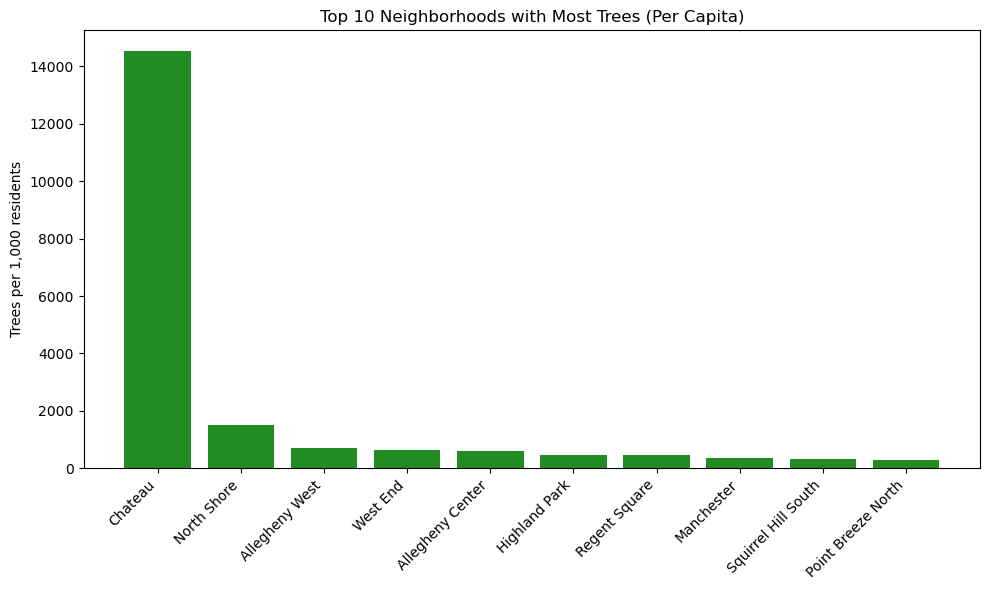

In [21]:
# top 10 neighborhoods for trees per capita
top10_trees = tree_metrics_sorted.sort_values("Trees_per_1000", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10_trees["Neighborhood_fixed"], top10_trees["Trees_per_1000"], color="forestgreen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Trees per 1,000 residents")
plt.title("Top 10 Neighborhoods with Most Trees (Per Capita)")
plt.tight_layout()
plt.show()


This cell ranks and plots the ten neighborhoods with the most trees per 1,000 residents. It highlights where tree access is strongest after accounting for population, showing that smaller neighborhoods can outperform larger ones if their trees are more accessible to residents.

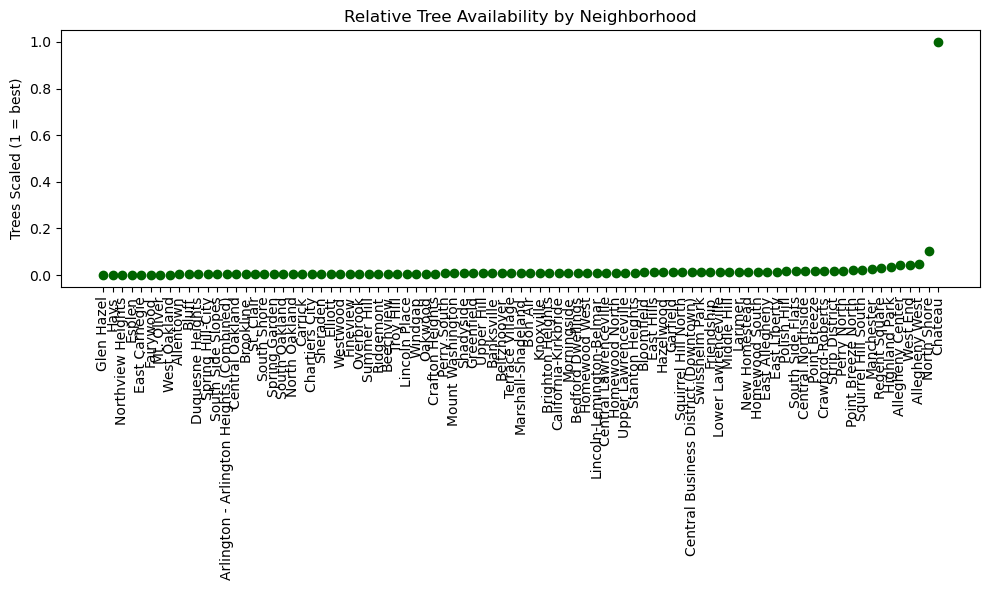

In [22]:
# scale so that 1 = best (most trees), 0 = worst (fewest trees)
t_min = tree_metrics["Trees_per_1000"].min()
t_max = tree_metrics["Trees_per_1000"].max()

if t_max == t_min:
    tree_metrics["Trees_Scaled"] = 1.0
else:
    tree_metrics["Trees_Scaled"] = (
        (tree_metrics["Trees_per_1000"] - t_min) / (t_max - t_min)
    )

# sort again, just to have a clean order for plotting
tree_metrics_sorted2 = tree_metrics.sort_values("Trees_per_1000", ascending=True)

plt.figure(figsize=(10, 6))
plt.scatter(tree_metrics_sorted2["Neighborhood_fixed"], tree_metrics_sorted2["Trees_Scaled"], color="darkgreen")
plt.xticks(rotation=90)
plt.ylabel("Trees Scaled (1 = best)")
plt.title("Relative Tree Availability by Neighborhood")
plt.tight_layout()
plt.show()


This cell scales trees per capita to a 0–1 score, where higher values mean better access. The scatter plot shows how each neighborhood fits on this metric, creating a standardized Trees_Scaled value that can be combined with other measures later.

In [23]:
# ordered from strongest greenery to weakest
tree_final_sorted = tree_metrics.sort_values("Trees_Scaled", ascending=False)

tree_final_sorted.head(15)



,Neighborhood_fixed,Tree_Count,2020_Total_Population,Trees_per_1000,Trees_Scaled
20,Chateau,276,19,14526.315789,1.000000
55,North Shore,457,301,1518.272425,0.104332
1,Allegheny West,386,540,714.814815,0.049010
85,West End,131,205,639.024390,0.043791
0,Allegheny Center,867,1419,610.993658,0.041861
38,Highland Park,2941,6235,471.692061,0.032269
64,Regent Square,434,971,446.961895,0.030567
47,Manchester,707,2031,348.104382,0.023760
75,Squirrel Hill South,5073,15317,331.200627,0.022596
62,Point Breeze North,566,1988,284.708249,0.019395


This cell ranks neighborhoods by their Trees_Scaled scores and previews the top fifteen. Tree data has now been reduced to a comparable metric that can be merged with crime and complaint scores for an overall quality-of-life analysis.

## Conclusion ##

Overall, the trees analys moves from simple counts to which a more in-depth calculation. I looked at which neighborhoods had the most trees and what condition those trees are in but this is still tied to raw totals. By combining the trees data with population, and converting trees per capita into a scaled score, I am able to focus on how much greenery every resident is able to enjoy. Using this I was able to determine that the best stress-relieving neighborhood is **Chateau**. 


## **Combine All Submetrics**

In this section of the notebook we combine all the different metrics to complete our entire Quality of Life metric. We use the 3 scaled data sets to achieve a better picture of the overall best neighborhood. 

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# shared data loading
# -------------------------
crime_df      = pd.read_csv("Crime Final Project.csv", low_memory=False)
trees_df      = pd.read_csv("Trees.csv", low_memory=False)
complaints_df = pd.read_csv("Complaints.zip", compression="zip", low_memory=False)
pop_df        = pd.read_csv("preliminarycitypittsburghneighborhood_pl94171summary-2.csv", low_memory=False)

# -------------------------
# shared name cleaning
# -------------------------
def fix_name(s):
    if pd.isna(s):
        return s
    return s.strip().replace("–", "-").replace("—", "-")

# normalize names in each dataframe
crime_df["Neighborhood_norm"]      = crime_df["Neighborhood"].map(fix_name)
trees_df["Neighborhood_norm"]      = trees_df["neighborhood"].map(fix_name)
complaints_df["Neighborhood_norm"] = complaints_df["NEIGHBORHOOD"].map(fix_name)
pop_df["Neighborhood_norm"]        = pop_df["Neighborhood"].map(fix_name)

# combined-neighborhood mapping (same as in the other notebooks)
combine = {
    "Arlington": "Arlington - Arlington Heights (Combined)",
    "Arlington Heights": "Arlington - Arlington Heights (Combined)",
    "Central Business District": "Central Business District (Downtown)",
    "Chartiers": "Chartiers City",
    "Mount Oliver": "Mt. Oliver",
    "Saint Clair": "St. Clair",
    "Southshore": "South Shore",
    "Spring Hill-City View": "Spring Hill-City"
}

crime_df["Neighborhood_fixed"]      = crime_df["Neighborhood_norm"].replace(combine)
trees_df["Neighborhood_fixed"]      = trees_df["Neighborhood_norm"].replace(combine)
complaints_df["Neighborhood_fixed"] = complaints_df["Neighborhood_norm"].replace(combine)


This cell standardizes neighborhood names across all four datasets so they can be merged. Aligning labels ensures crime, trees, complaints, and population all refer to the same places before combining them into a shared analysis.

In [25]:
# -------------------------
# merge Crime, Complaints, Trees into a single QoL table
# -------------------------

# select only needed columns from each
crime_sel = crime_metrics[["Neighborhood_fixed", "Crime_Scaled"]]
trees_sel = tree_metrics[["Neighborhood_fixed", "Trees_Scaled"]]
compl_sel = complaints_metrics[["Neighborhood_fixed", "Complaints_Scaled"]]

# inner joins: keep only neighborhoods present in all three datasets
qol_df = (
    crime_sel
    .merge(compl_sel, on="Neighborhood_fixed", how="inner")
    .merge(trees_sel, on="Neighborhood_fixed", how="inner")
)

# compute Quality of Life score
qol_df["QoL_Score"] = (
    0.50 * qol_df["Crime_Scaled"] +
    0.35 * qol_df["Complaints_Scaled"] +
    0.15 * qol_df["Trees_Scaled"]
)

# sort best to worst
qol_sorted = qol_df.sort_values("QoL_Score", ascending=False)

qol_sorted.head(15)


,Neighborhood_fixed,Crime_Scaled,Complaints_Scaled,Trees_Scaled,QoL_Score
54,North Oakland,0.999267,0.997168,0.004782,0.849360
74,Squirrel Hill North,0.999946,0.991483,0.011865,0.848772
38,Highland Park,0.997833,0.981373,0.032269,0.847238
87,Westwood,0.999216,0.989694,0.005164,0.846775
75,Squirrel Hill South,0.998465,0.982815,0.022596,0.846607
9,Bluff,0.995570,0.995603,0.002390,0.846604
66,Shadyside,0.996830,0.991879,0.006795,0.846592
4,Banksville,0.998247,0.988573,0.007082,0.846186
64,Regent Square,0.998616,0.977710,0.030567,0.846092
80,Swisshelm Park,1.000000,0.982416,0.012390,0.845704


This cell merges the scaled metrics and applies weights to crime, complaints, and trees based on their impact on daily life. The resulting Quality of Life Score combines safety, disruption, and environmental access into one measure of overall neighborhood livability.

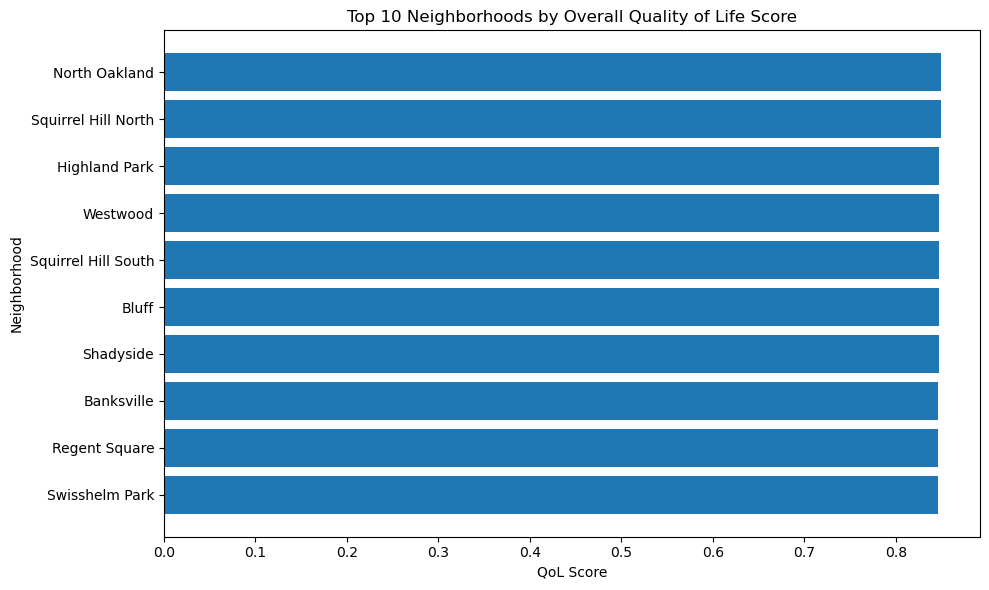

In [26]:
# top 10 neighborhoods by overall QoL
top10_qol = qol_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_qol["Neighborhood_fixed"], top10_qol["QoL_Score"])
plt.gca().invert_yaxis()
plt.xlabel("QoL Score")
plt.ylabel("Neighborhood")
plt.title("Top 10 Neighborhoods by Overall Quality of Life Score")
plt.tight_layout()
plt.show()


This cell compares the QoL score to each factor using scatter plots. The relationships show how crime, complaints, and trees contribute to livability and reveal outliers, emphasizing that neighborhood quality depends on multiple dimensions rather than a single variable.


## **The Best Neighborhood**

In [27]:
qol_sorted.head(1)

,Neighborhood_fixed,Crime_Scaled,Complaints_Scaled,Trees_Scaled,QoL_Score
54,North Oakland,0.999267,0.997168,0.004782,0.84936


By combining all the different metrics we concluded that **North Oakland** was the best overall neighborhood. This was actually not that large of a surprise in the end, given that North Oakland was in both the Complaints and Crime, the two most heavily weighted submetrics, top 10. 


## **Final Conclusions**


Our group came into this project assuming that Squirrel HIll would rank as the best neighborhood in Pittsburgh. We liked it personally becasue of its food options, nice views from the bridges, and the safe feeling created by the nice houses and popular restaurants. It seemed like the type of place that would naturally score at the top of any Quality of Life measure. 

However, the data challenged that assumption. By weighing crime severity, adjusting for population, and scaling trees and complaints into shared metrics, our analysis showed that livability depends on more than what looks clean or welcoming on the surface. Some neighborhoods that seemed quieter or less "upscale" ended up scoring higher because they offered lower disruption per resident or better tree access. The result shows how easily personal impressions can overlook what residents actually experience day-to-day. 

This doesn't make Squirrel Hill a bad neighborhood; it just means that our judgement was based on visible signals rather than measurable conditions. The analysis changed how I think about what it means for a place to be "The Best". It showed that quality of life is not just about how a neighborhood feels when you visit it, but how it performs for the people who live there. By looking at how it performs the people who live there we concluded that **North Oakland** was the best neighborhood. 
